In [1]:
import h5py
import numpy as np
from pathlib import Path
from package.texture_tomography.operators.pfo_single_material import PFO_SINGLE, estimate_L_power
import yaml
from package.texture_tomography.optimization.fista_opencl import FISTAOpenCL
from package.texture_tomography.optimization.fista_huber_opencl import FISTAHuberOpenCL
from package.texture_tomography.gpu_live_tracker import GPUMemoryLogger
import pyopencl.array as clarray
from package.texture_tomography.multiresolution_refiner import OrientationTree
from package.texture_tomography.material import Material
import matplotlib.pyplot as plt
from orix import plot, sampling
from orix.crystal_map import Phase
from orix.quaternion import Orientation, symmetry
from orix.vector import Vector3d
from scipy.spatial.transform import Rotation as R
from sklearn.neighbors import KDTree
import hdf5plugin


from tqdm import tqdm
import pyFAI
# This is needed to import from the textom module
import sys
sys.path.append("..")
from package import sparse

INFO:Setting the number of threads to 8. If your physical cores are fewer than this number, you may want to use numba.set_num_threads(n), and os.environ["OPENBLAS_NUM_THREADS"] = f"{n}" to set the number of threads to the number of physical cores n.
INFO:Setting numba log level to WARNING.


In [2]:
with open('simulations/sim01.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

poni_path = cfg['poni_path']
datapath = cfg['datapath']
diffraction_file = cfg['diffraction_file']
Nx = cfg['Nx']
N_rot = cfg['N_rot']
N_chi = cfg['N_chi']
N_theta = cfg['N_theta']

scan_name = 'very_highly_deformed' # 'polycrystal20grains', 'highly_deformed', 'very_highly_deformed'
h5path = datapath + f'/{scan_name}/s3dxrd.h5'

In [3]:
N_positions = Nx
N_rotations = N_rot
detector_shape = (2048, 2048)
rotation_index = N_rotations//2
position_index = N_positions//2


ai = pyFAI.load(poni_path)
mask = np.zeros(detector_shape, dtype = bool)

npt_rad = 2000
npt_azim = 180

INFO:No sensor configuration provided; using default behaviour.
INFO:Unable to parse `/dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/simulations/textom/azimuthal_integration/Eiger_4M.poni` as JSON file, defaulting to PoniParser
INFO:No sensor configuration provided; using default behaviour.


In [4]:
print(h5path)

/dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/simulations/textom/data/scans/very_highly_deformed/s3dxrd.h5


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 103/103 [03:07<00:00,  1.82s/it]


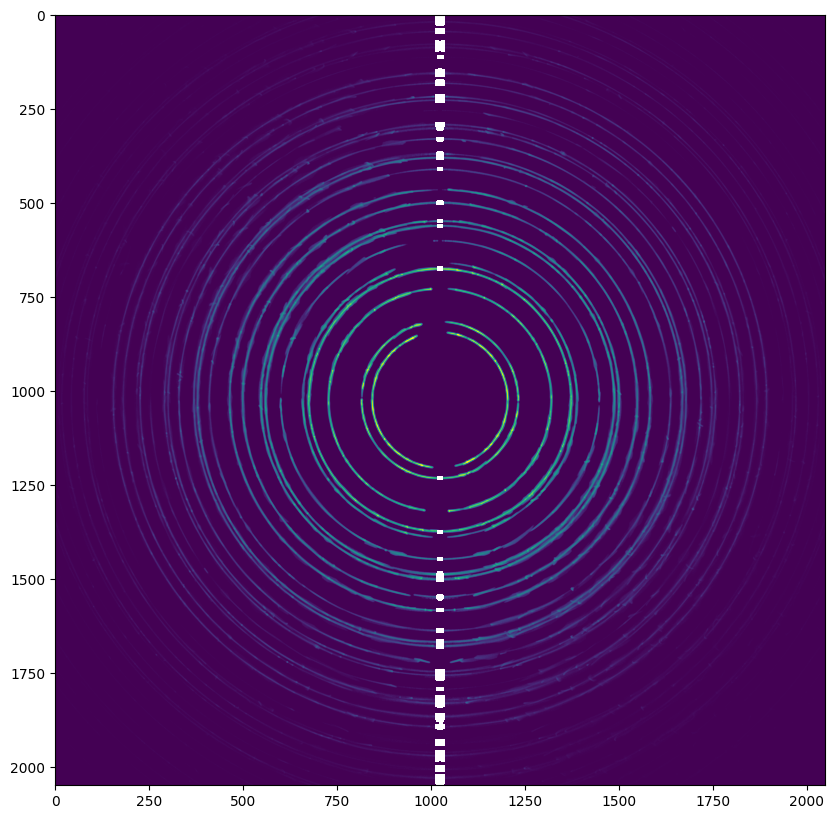

In [5]:
# Compute sum frame to do powder-diffraction indexing on
sum_frame = np.zeros(detector_shape) 

with h5py.File(h5path, 'r') as hf:
    for position_index in tqdm(range(N_positions)):
        for rotation_index in range(N_rotations):
            scan_key = f'{position_index+1:d}.1'
            sum_frame+=sparse.densify(hf, scan_key, frame_number=rotation_index)

plt.figure(figsize = (10, 10))
plt.imshow(np.log10(sum_frame+1e0), vmin = 0, vmax = 3)
plt.show()

In [6]:
# get some experimental parameters from the datafile
with h5py.File(h5path, 'r') as hf:
    print(hf['metadata'].keys())
    wvlnthg = float(hf['metadata/wavelength'][...])
    pixsize = float(hf['metadata/eiger/pixelsize_y'][...])
    det_dist = float(hf['metadata/eiger/distance'][...])

    latt_params = np.array(hf['metadata/sample/lattice/reference_cell'][...])

<KeysViewHDF5 ['eiger', 'motors', 'sample', 'wavelength']>


[[4.0493 0.     0.    ]
 [0.     4.0493 0.    ]
 [0.     0.     4.0493]]


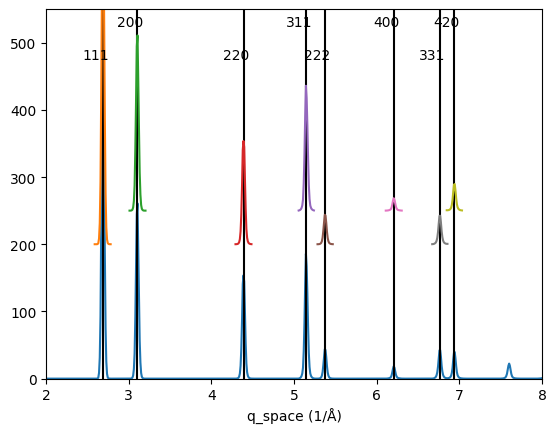

In [12]:
q_bin_width = 0.1
summed_curve, q_axis,_  = ai.integrate2d(sum_frame, npt_rad, npt_azim, mask=mask, method=("no", "csr", "opencl"))
summed_curve = summed_curve.sum(axis=0)/npt_azim
q_axis = q_axis/10 # Convet from 1/nm to 1/Å

plt.plot(q_axis, summed_curve)
plt.xlim(2, 8)
plt.ylim(0, 550)
plt.xlabel('q_space (1/Å)')


A  = np.eye(3) * latt_params[0]
B = 2*np.pi*np.linalg.inv(A).T
print(A)
hkl_list = [(1,1,1), (2, 0, 0), (2, 2, 0), (3, 1, 1), (2, 2, 2), (4, 0, 0), (3, 3, 1), (4, 2, 0)]
two_theta_list = []
two_theta_range_list = []

q_length_list = []
q_length_range_list = []

for ih, hkl in enumerate(hkl_list):

    q_vec = B @ np.array(hkl)
    q_length = np.linalg.norm(q_vec)
    #theta = np.arcsin( np.linalg.norm(q_vec) * wvlnthg / 4 / np.pi ) * 180 / np.pi
    #two_theta_list.append(2*theta)
    q_length_list.append(q_length)

    plt.plot([q_length]*2, [0, 550], 'k-')
    plt.text(q_length-0.25, 50*(ih%2) + 475, f'{hkl[0]}{hkl[1]}{hkl[2]}', color = 'k')

    #plt.plot([2*theta]*2, [0, 550], 'k-')
    #plt.text(2*theta-0.25, 50*(ih%2) + 475, f'{hkl[0]}{hkl[1]}{hkl[2]}', color = 'k')

    q_length_range = np.logical_and(q_axis >= q_length - q_bin_width, q_axis < q_length+ q_bin_width)
    q_length_range_list.append(q_length_range)
    
    plt.plot(q_axis[q_length_range], summed_curve[q_length_range] + 50*(ih%2) + 200)

In [8]:
# Now that all set_up is done, do the actual integration
data_array = np.zeros((N_rotations, N_positions, 1, npt_azim, len(hkl_list)))
with h5py.File(h5path, 'r') as hf:
    # Loop over frames
    for position_index in tqdm(range(N_positions)):
        for rotation_index in range(N_rotations):

            # Load and integrate
            scan_key = f'{position_index+1:d}.1'
            frame = sparse.densify(hf, scan_key, frame_number=rotation_index)
            integration = ai.integrate2d(frame, npt_rad, npt_azim, mask=mask, method=("no", "csr", "opencl"))

            # Loop over Bragg-peaks
            for ih, q_length_range in enumerate(q_length_range_list):
                data_array[rotation_index, position_index, 0, :, ih] = np.sum(integration[0][:, q_length_range], axis = 1)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 103/103 [03:38<00:00,  2.12s/it]


1092567.0726316904
6744105.9784463495


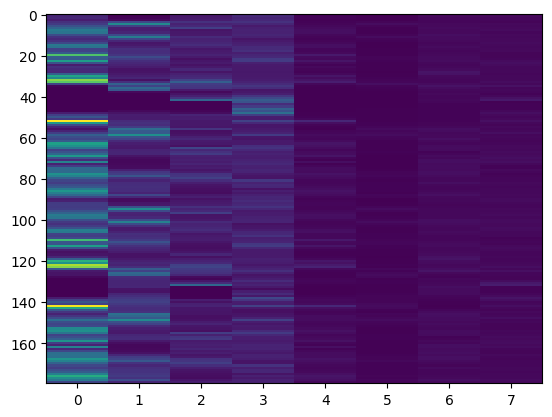

In [9]:
plt.imshow(np.sum(data_array[:,:,0],axis=(0,1)), aspect='auto', interpolation='nearest')
print(np.sum(data_array))
print(np.sum(sum_frame[sum_frame<100000000]))

In [10]:
for ih, hkl in enumerate(hkl_list):

    q_vec = B @ np.array(hkl)

    print(np.linalg.norm(q_vec))

for ih, q_length_range_range in enumerate(q_length_range_list):
    print(integration.radial[q_length_range])

2.68757468831781
3.103343939535024
4.388791087998781
5.146313721430525
5.37514937663562
6.206687879070048
6.763581309741284
6.939288006362311
[68.4634662  68.55127283 68.63907946 68.72688609 68.81469271 68.90249934
 68.99030597 69.07811259 69.16591922 69.25372585 69.34153247 69.4293391
 69.51714573 69.60495236 69.69275898 69.78056561 69.86837224 69.95617886
 70.04398549 70.13179212 70.21959874 70.30740537]
[68.4634662  68.55127283 68.63907946 68.72688609 68.81469271 68.90249934
 68.99030597 69.07811259 69.16591922 69.25372585 69.34153247 69.4293391
 69.51714573 69.60495236 69.69275898 69.78056561 69.86837224 69.95617886
 70.04398549 70.13179212 70.21959874 70.30740537]
[68.4634662  68.55127283 68.63907946 68.72688609 68.81469271 68.90249934
 68.99030597 69.07811259 69.16591922 69.25372585 69.34153247 69.4293391
 69.51714573 69.60495236 69.69275898 69.78056561 69.86837224 69.95617886
 70.04398549 70.13179212 70.21959874 70.30740537]
[68.4634662  68.55127283 68.63907946 68.72688609 68.81

In [11]:
# Save integrated data to disk
with h5py.File(datapath + f'/{scan_name}_integrated_data.h5', 'w') as out_file:

    out_file.create_dataset('data_array', data = data_array)
    out_file.create_dataset('twotheta_angles', data = two_theta_list)
    out_file.create_dataset('lattice', data = A)
    out_file.create_dataset('wavelength', data = wvlnthg)
    out_file.create_dataset('hkl_list', data = np.stack(hkl_list, axis = 0))

In [3]:
#!/usr/bin/env python3

import re
from pathlib import Path
import h5py


# ====== SET YOUR SCAN FOLDER HERE ======
SCAN_FOLDER = Path("/dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/simulations/textom/data/scans/highly_deformed")
# ========================================


SCAN_RE = re.compile(r"^scan_(\d+(?:\.\d+)?)\.h5$")


def merge_scans(folder: Path):
    if not folder.exists():
        raise FileNotFoundError(f"Folder does not exist: {folder}")

    output_path = folder / "s3dxrd.h5"

    if output_path.exists():
        raise FileExistsError(f"{output_path} already exists. Remove it first.")

    scan_files = []

    for f in folder.iterdir():
        match = SCAN_RE.match(f.name)
        if match:
            key_str = match.group(1)  # e.g. "1.1"
            scan_files.append((float(key_str), key_str, f))

    if not scan_files:
        raise RuntimeError("No scan_*.h5 files found.")

    scan_files.sort(key=lambda x: x[0])

    with h5py.File(output_path, "w") as fout:
        for _, key_str, fpath in scan_files:
            with h5py.File(fpath, "r") as fin:
                if key_str not in fin:
                    raise KeyError(
                        f"Dataset '{key_str}' not found in {fpath.name}"
                    )
                fin.copy(key_str, fout, name=key_str)

            print(f"Copied {fpath.name}:{key_str}")

    print(f"\nDone. Created {output_path}")


merge_scans(SCAN_FOLDER)


Copied scan_1.1.h5:1.1
Copied scan_2.1.h5:2.1
Copied scan_3.1.h5:3.1
Copied scan_4.1.h5:4.1
Copied scan_5.1.h5:5.1
Copied scan_6.1.h5:6.1
Copied scan_7.1.h5:7.1
Copied scan_8.1.h5:8.1
Copied scan_9.1.h5:9.1
Copied scan_10.1.h5:10.1
Copied scan_11.1.h5:11.1
Copied scan_12.1.h5:12.1
Copied scan_13.1.h5:13.1
Copied scan_14.1.h5:14.1
Copied scan_15.1.h5:15.1
Copied scan_16.1.h5:16.1
Copied scan_17.1.h5:17.1
Copied scan_18.1.h5:18.1
Copied scan_19.1.h5:19.1
Copied scan_20.1.h5:20.1
Copied scan_21.1.h5:21.1
Copied scan_22.1.h5:22.1
Copied scan_23.1.h5:23.1
Copied scan_24.1.h5:24.1
Copied scan_25.1.h5:25.1
Copied scan_26.1.h5:26.1
Copied scan_27.1.h5:27.1
Copied scan_28.1.h5:28.1
Copied scan_29.1.h5:29.1
Copied scan_30.1.h5:30.1
Copied scan_31.1.h5:31.1
Copied scan_32.1.h5:32.1
Copied scan_33.1.h5:33.1
Copied scan_34.1.h5:34.1
Copied scan_35.1.h5:35.1
Copied scan_36.1.h5:36.1
Copied scan_37.1.h5:37.1
Copied scan_38.1.h5:38.1
Copied scan_39.1.h5:39.1
Copied scan_40.1.h5:40.1
Copied scan_41.1.h

In [11]:
src_path = datapath + "/polycrystal20grains/s3dxrd.h5"
dst_path = datapath + "/very_highly_deformed/s3dxrd.h5"

with h5py.File(src_path, "r") as f_src, \
     h5py.File(dst_path, "a") as f_dst:

    # Remove existing group if it already exists
    if "metadata" in f_dst:
        del f_dst["metadata"]

    # Copy entire group recursively
    f_src.copy("metadata", f_dst)